Dataset Shape: (6064, 24)

Column Names:
 ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_lum', 'st_met', 'pl_insol', 'Target_Habitability', 'Habitability_Score', 'Steller_Compatibility', 'Orbital_Stability_Score', 'Star_Type_A', 'Star_Type_B', 'Star_Type_D', 'Star_Type_F', 'Star_Type_G', 'Star_Type_K', 'Star_Type_L', 'Star_Type_M', 'Star_Type_T', 'Star_Type_W', 'Stellar_Compatibility']

First 5 Rows:
    pl_rade  pl_bmasse  pl_orbper  pl_orbsmax    pl_eqt   st_teff    st_lum  \
0 -0.357554   4.112518  -0.024711   -0.037713 -0.093477 -0.384423  3.966854   
1 -0.357554   3.899939  -0.023503   -0.036641 -0.093477 -0.857096  0.056449   
2 -0.357554   0.616646  -0.025565   -0.038940 -0.093477 -0.374412  3.706981   
3 -0.357554   1.936297  -0.015686   -0.032852 -0.093477  0.098977  0.056449   
4 -0.357554   0.094249  -0.021736   -0.036245 -0.093477  0.241994  0.056449   

     st_met  pl_insol  Target_Habitability  ...  Star_Type_B  Star_Type_D  \
0 -1.769338 -0

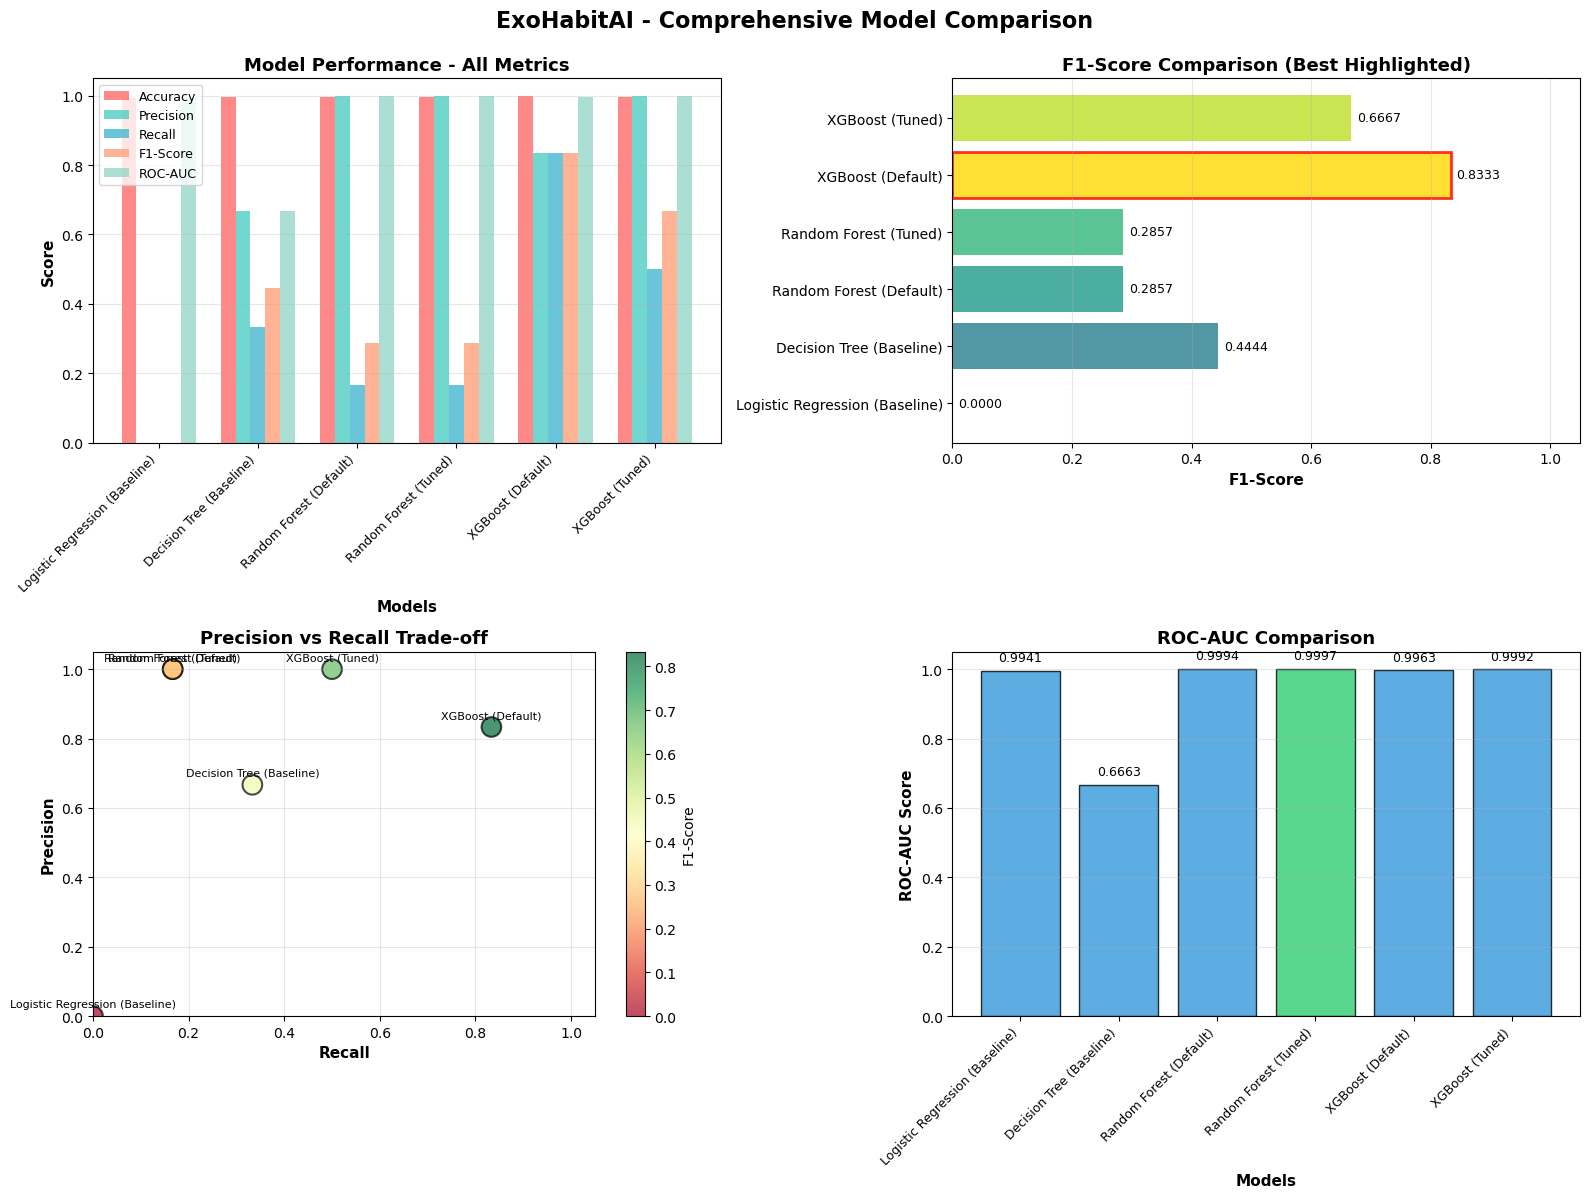


✅ Model comparison dashboard saved: model_comparison_dashboard.png

  CONFUSION MATRIX VISUALIZATION


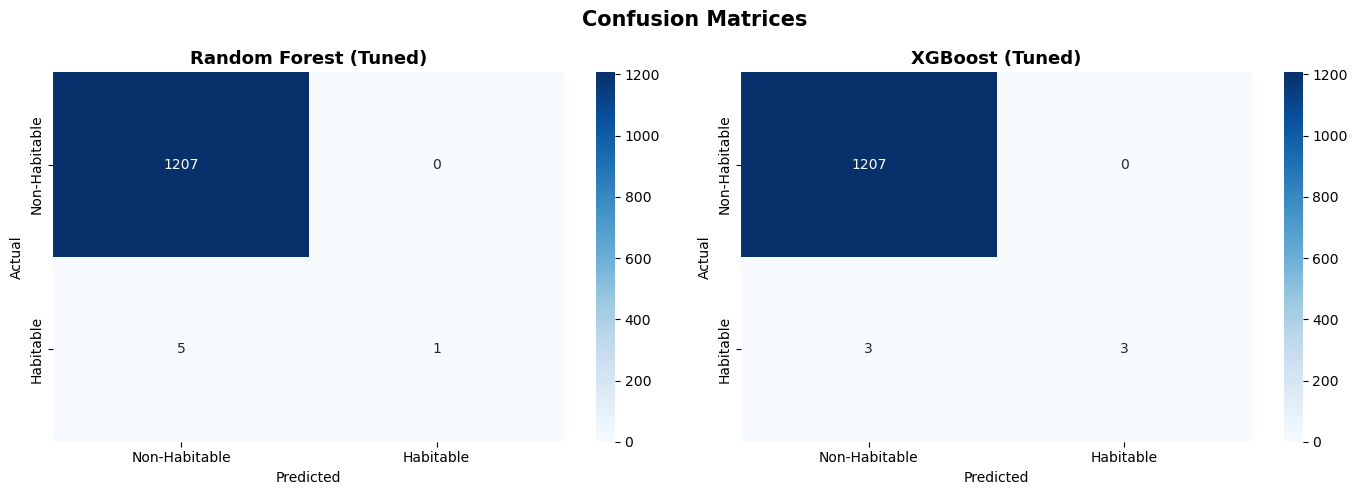

✅ Confusion matrices saved: confusion_matrices.png

  ROC CURVE VISUALIZATION


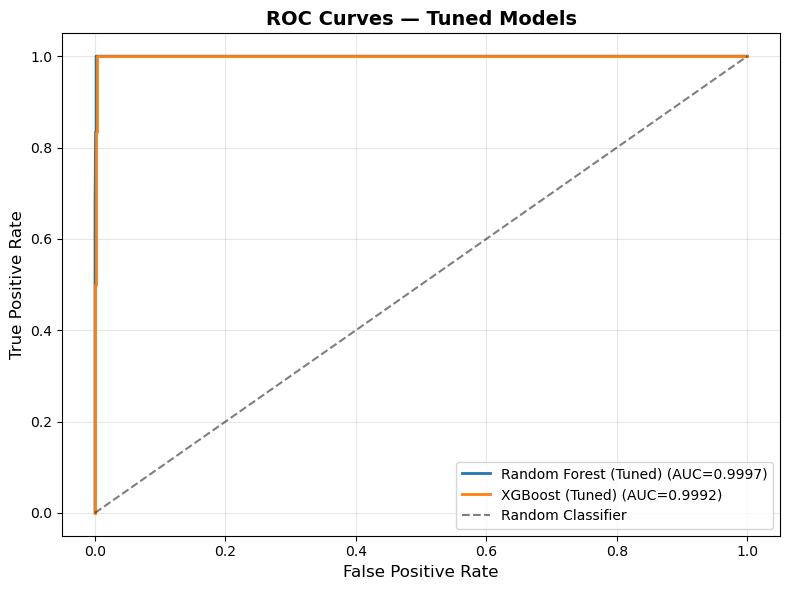

✅ ROC curves saved: roc_curves.png

  FEATURE IMPORTANCE VISUALIZATION


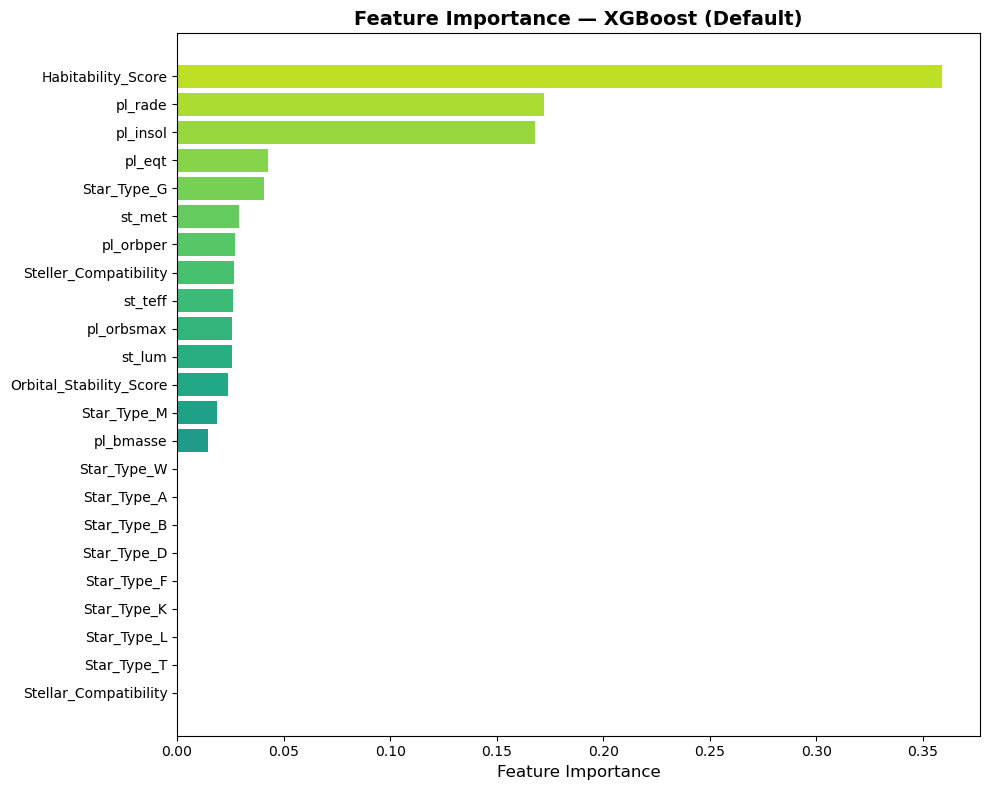

✅ Feature importance saved: feature_importance.png

Top 5 Contributing Features:
           Feature  Importance
       Star_Type_G    0.040642
            pl_eqt    0.042826
          pl_insol    0.168066
           pl_rade    0.171964
Habitability_Score    0.358859

  HABITABILITY SCORING & RANKING

Top 10 Most Habitable Exoplanets:
      Habitability_Probability  Habitability_Rank  Predicted_Habitability
3264                  0.998376                  1                       1
2990                  0.998218                  2                       1
5707                  0.997260                  3                       1
4086                  0.995831                  4                       1
5708                  0.995547                  5                       1
2985                  0.994992                  6                       1
4091                  0.994083                  7                       1
2276                  0.990233                  8                       

In [1]:
# ExoHabitAI - ML Model Training (COMPLETE WITH ALL VISUALIZATIONS)
# =====================================================================
# Objective: Train, evaluate, and finalize the best ML model for 
# predicting exoplanet habitability using preprocessed data.

# ============================================================
# 1. Importing Necessary Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 2. Loading Preprocessed Dataset
# ============================================================
df = pd.read_csv("pre-processedd.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. Separating Features (X) and Target (y)
# ============================================================
target_col = "Target_Habitability"

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nTarget Distribution:\n{y.value_counts()}")
print(f"\nTarget Ratio:\n{y.value_counts(normalize=True).round(4)}")


# ============================================================
# 4. Train-Test Split (80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")


# ============================================================
# 5. Helper Function — Model Evaluation
# ============================================================
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate a model and print all required metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}" if isinstance(roc_auc, float) else f"  ROC-AUC:   {roc_auc}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


# ============================================================
# 6. Baseline Models
# ============================================================
# 6.1 Logistic Regression (Baseline)
print("\n" + "="*60)
print("  BASELINE MODELS")
print("="*60)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression (Baseline)")

# 6.2 Decision Tree (Baseline — Shallow)
dt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])
dt_pipeline.fit(X_train, y_train)
dt_results = evaluate_model(dt_pipeline, X_test, y_test, "Decision Tree (Baseline)")


# ============================================================
# 7. Primary Model — Random Forest Classifier
# ============================================================
print("\n" + "="*60)
print("  PRIMARY MODEL 1: RANDOM FOREST")
print("="*60)

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

# Train with default parameters first
rf_pipeline.fit(X_train, y_train)
rf_results_default = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest (Default)")


# ============================================================
# 8. Primary Model — XGBoost Classifier
# ============================================================
print("\n" + "="*60)
print("  PRIMARY MODEL 2: XGBOOST")
print("="*60)

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ))
])

# Train with default parameters first
xgb_pipeline.fit(X_train, y_train)
xgb_results_default = evaluate_model(xgb_pipeline, X_test, y_test, "XGBoost (Default)")


# ============================================================
# 9. Hyperparameter Tuning — Random Forest (GridSearchCV)
# ============================================================
print("\n" + "="*60)
print("  HYPERPARAMETER TUNING: RANDOM FOREST")
print("="*60)

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
rf_grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid_search.best_params_}")
print(f"Best CV F1-Score: {rf_grid_search.best_score_:.4f}")

rf_best = rf_grid_search.best_estimator_
rf_results_tuned = evaluate_model(rf_best, X_test, y_test, "Random Forest (Tuned)")


# ============================================================
# 10. Hyperparameter Tuning — XGBoost (RandomizedSearchCV)
# ============================================================
print("\n" + "="*60)
print("  HYPERPARAMETER TUNING: XGBOOST")
print("="*60)

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)
xgb_random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {xgb_random_search.best_params_}")
print(f"Best CV F1-Score: {xgb_random_search.best_score_:.4f}")

xgb_best = xgb_random_search.best_estimator_
xgb_results_tuned = evaluate_model(xgb_best, X_test, y_test, "XGBoost (Tuned)")


# ============================================================
# 11. Model Comparison & Selection
# ============================================================
print("\n" + "="*60)
print("  MODEL COMPARISON")
print("="*60)

all_results = [
    lr_results, dt_results,
    rf_results_default, rf_results_tuned,
    xgb_results_default, xgb_results_tuned,
]

comparison_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1-Score": r["f1_score"],
        "ROC-AUC": r["roc_auc"] if isinstance(r["roc_auc"], float) else 0,
    }
    for r in all_results
])

print("\n", comparison_df.to_string(index=False))

# Select best model based on F1-Score
best_idx = comparison_df["F1-Score"].idxmax()
best_model_name = comparison_df.loc[best_idx, "Model"]
print(f"\n✅ Best Model: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"   Recall:   {comparison_df.loc[best_idx, 'Recall']:.4f}")


# ============================================================
# 11.5 Model Comparison Visualization (NEW)
# ============================================================
print("\n" + "="*60)
print("  MODEL PERFORMANCE COMPARISON DASHBOARD")
print("="*60)

# Prepare data for visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = comparison_df['Model'].tolist()

# Create subplots for comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart - All metrics comparison
ax1 = axes[0, 0]
x = np.arange(len(models))
width = 0.15
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    ax1.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)

ax1.set_xlabel('Models', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Performance - All Metrics', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.05)

# 2. F1-Score comparison (focused)
ax2 = axes[0, 1]
f1_scores = comparison_df['F1-Score'].values
colors_f1 = plt.cm.viridis(np.linspace(0.3, 0.9, len(models)))
bars = ax2.barh(models, f1_scores, color=colors_f1, alpha=0.8)

# Highlight best model
best_f1_idx = comparison_df['F1-Score'].idxmax()
bars[best_f1_idx].set_color('#FFD700')
bars[best_f1_idx].set_edgecolor('red')
bars[best_f1_idx].set_linewidth(2)

ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score Comparison (Best Highlighted)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, 1.05)

# Add value labels
for i, (model, score) in enumerate(zip(models, f1_scores)):
    ax2.text(score + 0.01, i, f'{score:.4f}', va='center', fontsize=9)

# 3. Precision vs Recall scatter
ax3 = axes[1, 0]
precision_vals = comparison_df['Precision'].values
recall_vals = comparison_df['Recall'].values

scatter = ax3.scatter(recall_vals, precision_vals, 
                      s=200, c=f1_scores, cmap='RdYlGn', 
                      alpha=0.7, edgecolors='black', linewidth=1.5)

# Add labels to points
for i, model in enumerate(models):
    ax3.annotate(model, (recall_vals[i], precision_vals[i]), 
                 fontsize=8, ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

ax3.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision vs Recall Trade-off', fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.set_xlim(0, 1.05)
ax3.set_ylim(0, 1.05)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('F1-Score', fontsize=10)

# 4. ROC-AUC comparison
ax4 = axes[1, 1]
roc_auc_vals = comparison_df['ROC-AUC'].values
colors_auc = ['#2ECC71' if val == comparison_df['ROC-AUC'].max() 
              else '#3498DB' for val in roc_auc_vals]

bars_auc = ax4.bar(range(len(models)), roc_auc_vals, 
                    color=colors_auc, alpha=0.8, edgecolor='black')

ax4.set_xlabel('Models', fontsize=11, fontweight='bold')
ax4.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax4.set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
ax4.set_xticks(range(len(models)))
ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1.05)

# Add value labels
for i, (bar, val) in enumerate(zip(bars_auc, roc_auc_vals)):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ExoHabitAI - Comprehensive Model Comparison', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("model_comparison_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Model comparison dashboard saved: model_comparison_dashboard.png")


# ============================================================
# 12. Confusion Matrix Visualization
# ============================================================
print("\n" + "="*60)
print("  CONFUSION MATRIX VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, [rf_results_tuned, xgb_results_tuned]):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Non-Habitable", "Habitable"],
        yticklabels=["Non-Habitable", "Habitable"],
        ax=ax,
    )
    ax.set_title(f'{result["model_name"]}', fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Confusion matrices saved: confusion_matrices.png")


# ============================================================
# 13. ROC Curve Visualization
# ============================================================
print("\n" + "="*60)
print("  ROC CURVE VISUALIZATION")
print("="*60)

plt.figure(figsize=(8, 6))

for result in [rf_results_tuned, xgb_results_tuned]:
    if result["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
        auc_val = roc_auc_score(y_test, result["y_proba"])
        plt.plot(fpr, tpr, label=f'{result["model_name"]} (AUC={auc_val:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Tuned Models", fontsize=14, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ ROC curves saved: roc_curves.png")


# ============================================================
# 14. Feature Importance Plot
# ============================================================
print("\n" + "="*60)
print("  FEATURE IMPORTANCE VISUALIZATION")
print("="*60)

# Use the best model (choose RF or XGB based on results)
if "Random Forest" in best_model_name:
    final_model = rf_best
    importances = final_model.named_steps["model"].feature_importances_
else:
    final_model = xgb_best
    importances = final_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances,
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color=plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance_df))),
)
plt.xlabel("Feature Importance", fontsize=12)
plt.title(f"Feature Importance — {best_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Feature importance saved: feature_importance.png")
print("\nTop 5 Contributing Features:")
print(feature_importance_df.tail(5).to_string(index=False))


# ============================================================
# 15. Habitability Scoring & Ranking
# ============================================================
print("\n" + "="*60)
print("  HABITABILITY SCORING & RANKING")
print("="*60)

# Predict probabilities on full dataset
y_full_pred = final_model.predict(X)
y_full_proba = final_model.predict_proba(X)[:, 1]

output_df = df.copy()
output_df["Predicted_Habitability"] = y_full_pred
output_df["Habitability_Probability"] = y_full_proba
output_df["Habitability_Rank"] = output_df["Habitability_Probability"].rank(
    ascending=False, method="dense"
).astype(int)

# Sort by habitability probability (most habitable first)
output_df = output_df.sort_values("Habitability_Probability", ascending=False)

print("\nTop 10 Most Habitable Exoplanets:")
print(output_df[["Habitability_Probability", "Habitability_Rank", "Predicted_Habitability"]].head(10).to_string())


# ============================================================
# 16. Save Trained Models & Output
# ============================================================
print("\n" + "="*60)
print("  SAVING MODELS AND OUTPUTS")
print("="*60)

# Create directories
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Save models
joblib.dump(rf_best, "models/random_forest.pkl")
joblib.dump(xgb_best, "models/xgboost.pkl")
print("\n✅ Models saved:")
print("   models/random_forest.pkl")
print("   models/xgboost.pkl")

# Save output CSV
output_df.to_csv("data/processed/exohabit_ml_output.csv", index=False)
print("\n✅ ML output saved:")
print("   data/processed/exohabit_ml_output.csv")

# Save comparison table
comparison_df.to_csv("data/processed/model_comparison.csv", index=False)
print("   data/processed/model_comparison.csv")

print("\n" + "="*60)
print("  ✅ MODEL TRAINING COMPLETE")
print("="*60)
print(f"\n  Final Model: {best_model_name}")
print(f"  Total Exoplanets Scored: {len(output_df)}")
print(f"  Predicted Habitable: {(y_full_pred == 1).sum()}")
print(f"  Predicted Non-Habitable: {(y_full_pred == 0).sum()}")

print("\n" + "="*60)
print("  📊 VISUALIZATIONS GENERATED")
print("="*60)
print("  1. model_comparison_dashboard.png")
print("  2. confusion_matrices.png")
print("  3. roc_curves.png")
print("  4. feature_importance.png")
print("="*60)

In [3]:
import joblib

joblib.dump(xgb_model, "xgboost.pkl")


NameError: name 'xgb_model' is not defined

In [4]:
X.columns
print(X.shape)


(6064, 23)


In [5]:
X.columns


Index(['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_orbsmax', 'pl_eqt', 'st_teff',
       'st_lum', 'st_met', 'pl_insol', 'Habitability_Score',
       'Steller_Compatibility', 'Orbital_Stability_Score', 'Star_Type_A',
       'Star_Type_B', 'Star_Type_D', 'Star_Type_F', 'Star_Type_G',
       'Star_Type_K', 'Star_Type_L', 'Star_Type_M', 'Star_Type_T',
       'Star_Type_W', 'Stellar_Compatibility'],
      dtype='object')